# 04 — Patient summary evaluation

A health-worker briefing from structured data only. The packet never contains a name,
phone, address or calendar date. A model may rephrase; a post-check rejects invented
numbers or drugs and falls back to a template.

This notebook uses the same 200 packets as `make eval-summary`.

In [1]:
import sys, json, warnings
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve(); ROOT = ROOT if (ROOT / "D_Clinic_Backend").exists() else ROOT.parent
sys.path.insert(0, str(ROOT / "D_Clinic_Backend"))
from llm.check import check_summary, must_keep_facts
from llm.eval_summary import AS_OF, build_eval_set, pdsqi, sloppy_text
from llm.summary import summarize_packet
from llm.template import templated_summary
from llm.gateway import GatewayResult, PROMPT_VERSION
packets = build_eval_set(200)
print(len(packets), "packets", AS_OF)

200 packets 2026-09-26


## 1. What the model is allowed to see

In [2]:
p = packets[3]
pd.Series(p.to_prompt()).to_frame("packet")
print("hash", p.packet_hash()[:16], "case", p.case_code)
print(templated_summary(p))

hash b8d2c6fe77e24094 case C-EVAL003
35-44 female patient on the hypertension register. Last BP 142/88 (2 weeks ago), above the 140/90 program target. Current drugs: Amlodipine 10 mg, Telmisartan 80 mg. Attendance: 5 visits in 12 months, 3 missed; last visit 2 weeks ago; overdue by 15 days. Last call (6 days ago): removed from overdue list. Missed-visit risk band low, basis personal (uncontrolled BP). Confirm the last reading and follow the HEARTS next-step table; do not change drugs from this summary.


## 2. Post-check catches a hallucination

In [3]:
def sloppy_gw(text):
    return GatewayResult(text, "mock", "sloppy", PROMPT_VERSION, 1, None, None, None)
p = packets[3]
bad = sloppy_text(p)
print("unchecked extras", check_summary(bad, p))
res = summarize_packet(p, complete_fn=lambda _: sloppy_gw(bad))
print("pipeline", res.check, res.fallback_used)
print(res.summary)
assert res.fallback_used and "200/130" not in res.summary

unchecked extras CheckResult(ok=False, extra_numbers=['200', '130', '08031234567'], extra_drugs=['losartan'], missing_facts=[])
pipeline failed_fallback True
35-44 female patient on the hypertension register. Last BP 142/88 (2 weeks ago), above the 140/90 program target. Current drugs: Amlodipine 10 mg, Telmisartan 80 mg. Attendance: 5 visits in 12 months, 3 missed; last visit 2 weeks ago; overdue by 15 days. Last call (6 days ago): removed from overdue list. Missed-visit risk band low, basis personal (uncontrolled BP). Confirm the last reading and follow the HEARTS next-step table; do not change drugs from this summary.


## 3. Scores across 200 packets

,factuality,omission,words,pii,pdsqi
generator,,,,,
template,1.0,0.0,70.4,0.0,1.000
sloppy,0.0,0.0,81.4,1.0,0.556
pipeline,1.0,0.0,70.4,0.0,1.000


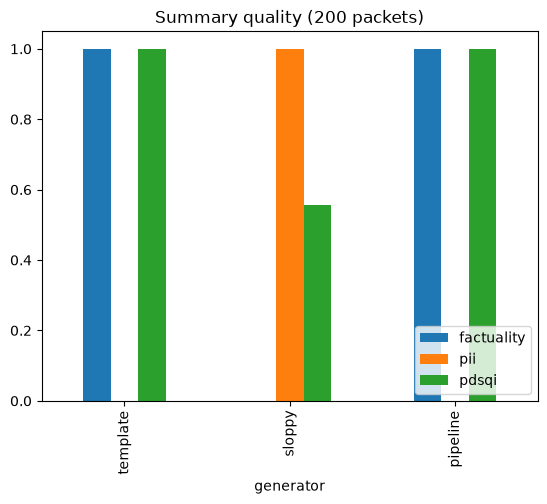

In [4]:
from llm.eval_summary import score_texts
rows = []
tmpl = [(p, templated_summary(p)) for p in packets]
sloppy = [(p, sloppy_text(p)) for p in packets]
pipe = []
for p in packets:
    r = summarize_packet(p, complete_fn=lambda _payload, _p=p: sloppy_gw(sloppy_text(_p)))
    pipe.append((p, r.summary))
for name, pairs in [("template", tmpl), ("sloppy", sloppy), ("pipeline", pipe)]:
    s = score_texts(name, pairs)
    rows.append({"generator": name, "factuality": s["factuality"], "omission": s["omission"],
                 "words": s["mean_words"], "pii": s["pii_rate"], "pdsqi": s["pdsqi_mean"]})
tab = pd.DataFrame(rows).set_index("generator")
ax = tab[["factuality", "pii", "pdsqi"]].plot.bar(title="Summary quality (200 packets)")
ax.set_ylim(0, 1.05); ax.legend(loc="lower right")
tab.round(3)

## 4. PDSQI-9-style items (template)

In [5]:
rubric = pd.DataFrame([pdsqi(templated_summary(p), p) for p in packets])
rubric.mean().round(3).to_frame("pass rate")

,pass rate
accuracy,1.0
completeness,1.0
medication_fidelity,1.0
bp_fidelity,1.0
no_identity,1.0
relative_time,1.0
length,1.0
actionability,1.0
no_overreach,1.0


## 5. Live provider

If `LLM_PROVIDER` is `ollama` or `openai`, `make eval-summary` adds a live row.
This notebook does not call a network model so it stays offline after setup.